# Desenho de arquitetura

A complexidade do deploy aumenta à medida em que precisamos de maior tempestividade, seja para atualizar o modelo ou para disponibilizá-lo. Nesse contexto, irei sugerir arquiteturas em ordem de complexidade de acordo com os requisitos. 

O modelo de referência será um XGBoost, mas provavelmente poderia ser adaptado para a maioria dos outros modelos. A arquitetura será baseada em serviços AWS para simplicidade, algumas ferramentas poderiam ser adaptadas para outros cenários de cloud.

## Predição MVP (Batch)

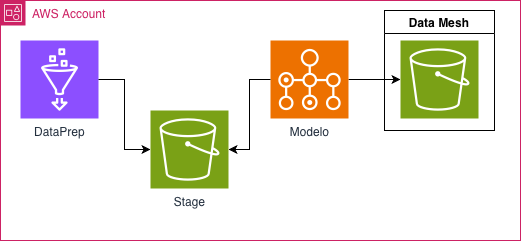

Uma arquitetura batch mínima envolveria a necessidade de recuperar dados de clientes, produtos, contratos e interações. O consumo de dados poderia ser feito via Glue. O modelo poderia ser executado em uma aplicação batch AWS Batch e os dados seriam salvos como uma tabela no DataMesh. As predições poderiam ser salvas por partições diárias, guardandos os resultados para todos os clientes e produtos elegíveis. 

É uma solução "mínima", mas com limitações:

* Dificuldade em atualizar modelos, que precisariam ser feito a partir de mudanças na imagem utiliza pelo AWS Batch.

* Nenhum acompanhamento de qualidade de dados, linhagem e drift (tanto de dados quanto resultados).

* Dificuldade em trabalhar com dados de baixa latência (e.g. logs de uso, transações recentes, contratações novas).


## Evoluções de qualidade e governança

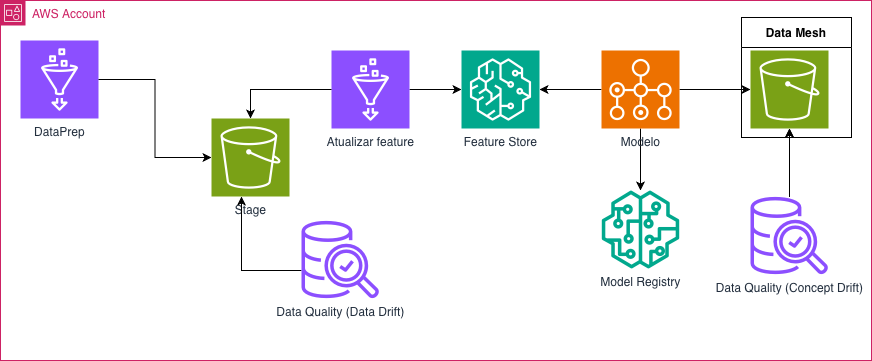

A partir dessa arquitetura inicial, podemos começar a evoluir para atacar essas limitações, nessa prioridade:

### 1. Calculando concept drift

Uma solução inicial de concept drift poderia ser aplicado direto nos dados democratizados. Utilizando um Glue Job especializado ou, se possível, adaptar as métricas do GDQ para cruzar com as bases relevantes (e.g. cliques, contratações, receita) e identificar possíveis degradação de desempenho. Caso se justifique, pode-se desenhar uma solução de notificações para determinaodos desvios observados.

A ideia é ter a primeira validação no passo final, dessa forma cobre o resultado mais importante. Entretanto, nesse cenário talvez já seja tarde demais, alguns problemas poderiam ser identificados em etapas anteriores com análise dos dados de entrada.

### 2. Adicionando data quality na origem

A primeira parte do processo de qualidade é validar se os dados da origem estão corretos, com isso podemos usar soluções como [Glue Data Quality](https://docs.aws.amazon.com/glue/latest/dg/glue-data-quality.html) para identificar problemas nas origens:

* dados obrigatórios faltantes;
* problemas de domínios de dados (e.g. produtos repetidos, novos produtos);
* identificar possíveis indisponibilidades de bases.
* acompanhamento de data drift automático.

Nessa camada, já seria possível implementar validações de "data drift" das variáveis, que podem tratar tando de erros no pipeline quando de mudanças na distribuição dos dados.

### 3. Usando registry de modelo

A solução inicial precisaria que o modelo fosse versionado junto com o código, sendo salvo diretamente na imagem dentro do ECR. É uma solução que mistura dois problemas distintos: aplicação que gera os resultados e definição do modelo.,

Seria interessante uma solução de [model registry](https://docs.aws.amazon.com/sagemaker/latest/dg/model-registry.html). Dessa forma, poderíamos desacoplar um retreino de uma mudança na aplicação, melhorando governança e acompanhamento das evoluções.

### 4. Usando feature store

Os dados poderiam ser salvos em uma feature store como o [Sagemaker Feature Store](https://aws.amazon.com/sagemaker/ai/feature-store/). Recursos especializados para modelagem podem agregar tanto na experimentação, quanto na produtização dos modelos:

* consultar as features no passado de forma consistente, evitando erros de cruzamento e vazamento de dados;
* pré-calcular features específicas;
* facilitar evolução para uma solução RT ou NRT.

## Evoluções de tempestividade

Os modelos não necessariamente precisam evoluir para NRT ou RT. Os próximos passos não seriam um roadmap, mas são propostas para lidar com novas necessidades do modelo, especialmente o uso de dados mais tempestivos.

### Predição Near Real Time.

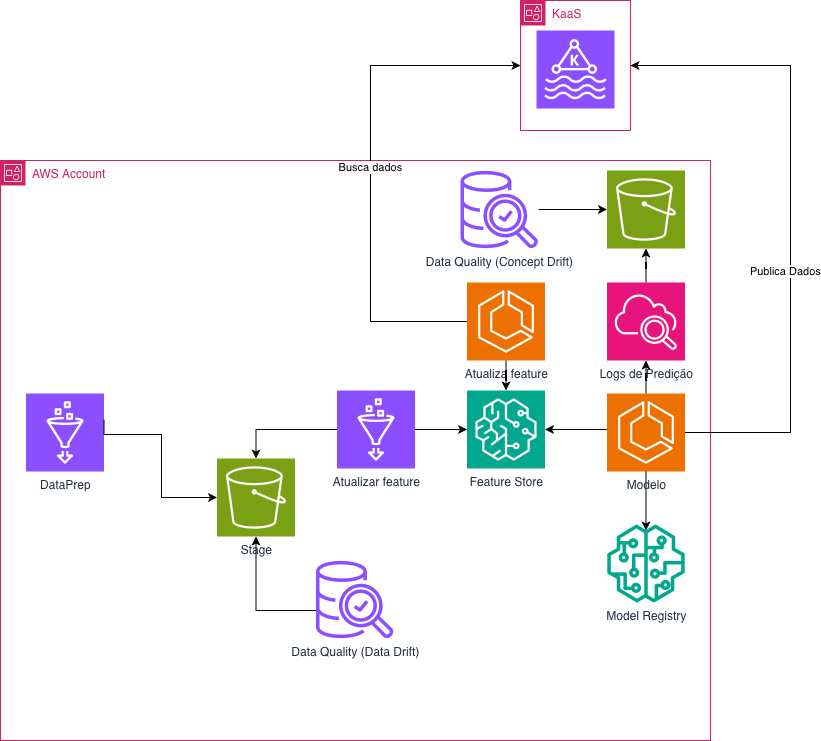

A arquitetura NRT seria importante para atualizar a predição do modelo a partir de eventos relevantes. Por exemplo, o cliente acabou de contratar um produto ou acessou uma tela de contratação, pode ser necessário recalcular o ranking do cliente com base nesses novos dados. Nessa arquitetura, as principais alterações seriam:

* Criar um "listener" para acompanhar eventos relevantes e atualizar o feature store. Poderia ser feito no próprio modelo, mas recomendaria separar essa reponsabilidade em outra aplicação.
* Migrar a modelo batch para um aplicação online, que pudesse ser notificada para reprocessar clientes a partir de eventos relevantes.
* Não seria recomendado salvar os dados no Mesh, porque os dados ficariam pouco otimizados para consumo dessa forma. Uma alternativa é publicar  em um tópico Kafka, que pode ser consumido pelos interessados na informação.
* Seria necessário registrar os dados de predição em logs para manter acompanhamento de "concept drift".

Os dados batches poderiam seguir da mesma maneira. O Feature Store precisa suportar as escritas e consultas em tempo real a nível de cliente, o que enxergo como maior desafio dessa evolução. Caso não haja uma solução de feature store online, elas precisariam ser armazenadas em um banco de dados como o DynamoDB por exemplo.

### Predição Real Time

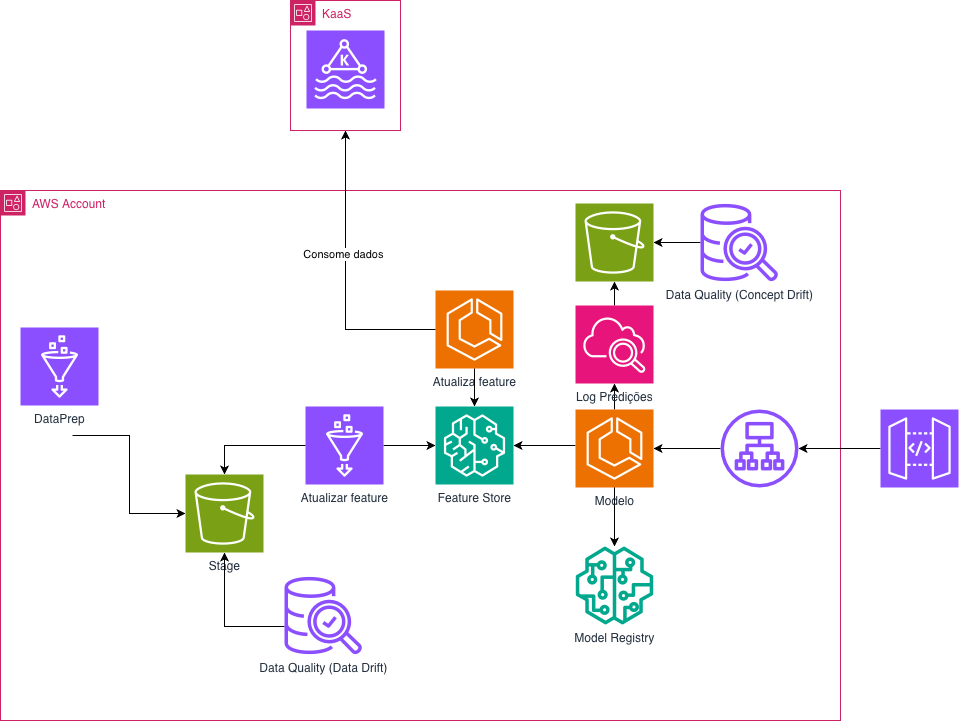


A predição real time é necessária se o modelo precisa de dados da requisição (e.g. canal de contato, horário da recomendação, contexto de navegação do app). Não são mudanças muito grandes comparados ao NRT em termos de desenho de solução, mas existem muito mais riscos e requisitos não funcionais:

* Ao receber uma requisição, é necessário buscar/transformar os dados e executar o modelo para o cliente. A expectativa de uma API síncrona é que isso seja feito em centenas de milissegundos no máximo, suportando picos de requisições. Para isso, a aplicação e o feature store devem estar bem dimensionados e deesenvolvidas.

* Atualizações de modelos podem ser arriscadas, menos agilidade para testes e evoluções.

* Pode limitar uso de modelos mais complexos, com maior tempo de predição e/ou preparação dos dados.

* Custos podem ser muito elevados, especialmente por ser necessário processar cada requisição

Em resumo, é uma solução que precisaria de muito valor de negócio para justificar a complexidade e riscos.

## Disponibilização via API (Real Time)

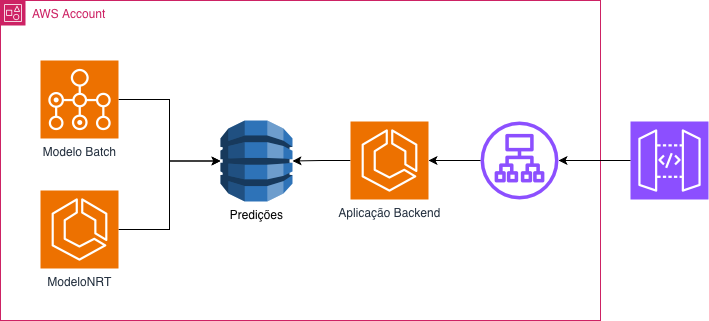

Um sistema de recomendação precisa ser acessado em real-time, mas não precisa ser calculado em real-time. Podemos disponibilizar os dados em uma API com predição batch ou NRT, evitando as dores de fazer uma predição em tempo real. Para isso, é necessário salvar as predições em uma base de dados de baixa latência como o Dynamo. A aplicação que recebe a chamada da API é responsável apenar por recuperar os dados e enviar para o consumidor.

Imagino que o cenário ideal seja predição NRT com disponibilização via API, que conseguimos ter mais tempestividade sem adicionar as complexidades de uma predição RT.

# Estratégia de validação A/B

A validação de A/B pode ser implementada de diversas formas, dependendo muito de como está a solução. Para efeitos de exemmplo, vou considerar o cenário de que estamos querendo comparar os resultados do baseline com um novo modelo. O tamanho da amostra foi calculado, as métricas e hipóteses do experimento estão definidas (e.g. aumentar em X% a receita com seguros). Para esse modelo, o cliente seriam separados em grupos: se o cliente X entrou no grupo A do experimento, todas as recomendações dele devem cair no mesmo grupo até o fim desse experimento.

No cenário em que não fazemos a disponibilização do modelo, seria necessário fazer a separação dos grupos no momento da predição. As predições seriam salvas com o grupo correspondente, o acompanhamento precisaria ser feito manualmente a partir do cruzamento de bases: cruzar as interações como o modelo usado para aquele cliente, validar se já temos eventos suficientes e calcular as métricas do experimento. Apesar do trabalhar manual, seria possivel implementar na arquitetura MVP esse pipeline.

É muito complexo desenhar as evoluções desse fluxo, porque ela dependeria de diversos fatores:

* Estamos fazendo predições em RT? Nesse cenário, podemos deixar múltiplos modelos online para realizar múltiplos experimentos.

* Existe uma plataforma de experimentação? Os testes podem ficar direto no app do banco por exemplo, apenas recebemos qual grupo o cliente está (A ou B) em nossas APIs. Nesse cenário, as métricas de engajamento poderiam ser calculadas diretamente pela plataforma.

* As métricas de decisão estão disponíveis? Uma métrica de cliques pode ser calculada segundos depois da interação, métricas de contratação provavelmente dependeria de cruzar com bases de negócio com algum atraso, dificultando a conclusão e automação do experimento.

# Lidando com Cold Start

O cenário de *cold start* para clientes não demanda nenhum tratamento especial para os modelos de boosting. Entretanto, o modelo teria problemas para lidar com novos produtos da forma que está hoje.

Entre as alternativas para contornar essa limitação, seria trabalhar com dados sintéticos ou simplesmente forçar um cenário de recomendação forçada. Essa recomendação forçada poderia ser feita na etapa de recomendação do modelo, sendo gerado para alguns clientes seguindo alguma regra ou aleatoriamente como uma estratégia de bandits.